<a href="https://colab.research.google.com/github/Lomada-Sahithi/Machine-Learning-Sem-5/blob/main/7_6_Decision_Tree_Classifier_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn import metrics

In [2]:
data = {
    'Age': [22, 25, 28, 32, 35, 38, 42, 45, 27, 31],
    'Income': [25, 30, 35, 45, 50, 55, 60, 70, 40, 48],
    'Buy_House': ['No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

print(df)

   Age  Income Buy_House
0   22      25        No
1   25      30        No
2   28      35        No
3   32      45       Yes
4   35      50       Yes
5   38      55       Yes
6   42      60       Yes
7   45      70       Yes
8   27      40        No
9   31      48       Yes


In [3]:
X = df[['Age', 'Income']]
y = df['Buy_House']

print("Input Variables (X):")
print(X)

print("\nTarget Variable (y):")
print(y)

Input Variables (X):
   Age  Income
0   22      25
1   25      30
2   28      35
3   32      45
4   35      50
5   38      55
6   42      60
7   45      70
8   27      40
9   31      48

Target Variable (y):
0     No
1     No
2     No
3    Yes
4    Yes
5    Yes
6    Yes
7    Yes
8     No
9    Yes
Name: Buy_House, dtype: object


In [4]:
y = y.map({'No': 0, 'Yes': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:")
print(X_train)

print("\nTesting data:")
print(X_test)

print("\nTraining target:")
print(y_train)

print("\nTesting target:")
print(y_test)

Training data:
   Age  Income
5   38      55
0   22      25
7   45      70
2   28      35
9   31      48
4   35      50
3   32      45
6   42      60

Testing data:
   Age  Income
8   27      40
1   25      30

Training target:
5    1
0    0
7    1
2    0
9    1
4    1
3    1
6    1
Name: Buy_House, dtype: int64

Testing target:
8    0
1    0
Name: Buy_House, dtype: int64


In [5]:
model = DecisionTreeClassifier(criterion='entropy', random_state=42)

model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [6]:
y_pred = model.predict(X_test)

print("Actual values:")
print(y_test.values)

print("\nPredicted values:")
print(y_pred)

Actual values:
[0 0]

Predicted values:
[0 0]


In [10]:
accuracy = metrics.accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy in percentage:", accuracy * 100, "%")

Accuracy: 1.0
Accuracy in percentage: 100.0 %


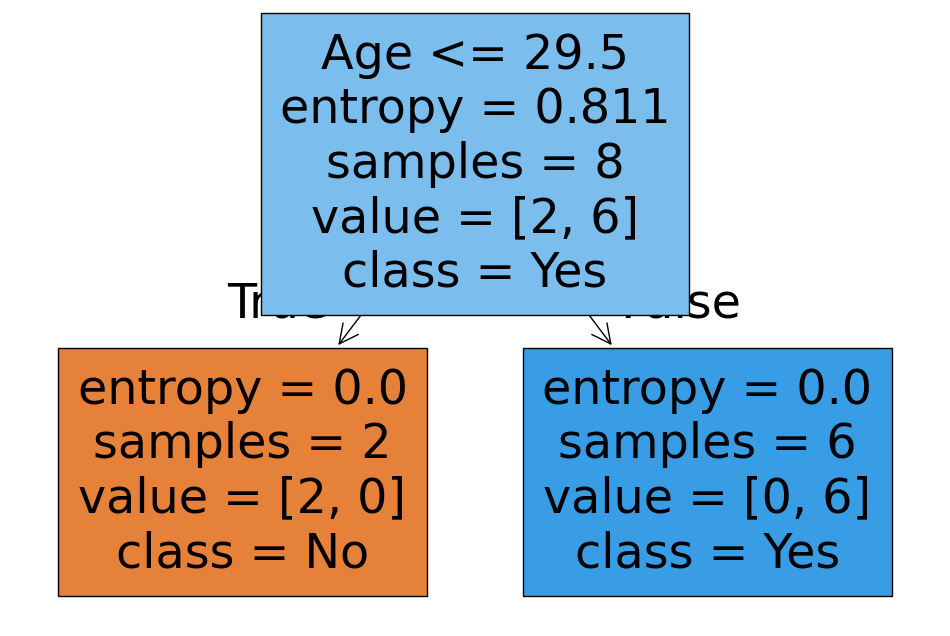

In [11]:
plt.figure(figsize=(12, 8))

tree.plot_tree(
    model,
    feature_names=['Age', 'Income'],
    class_names=['No', 'Yes'],
    filled=True
)

plt.show()

In [13]:
confusion_matrix = metrics.confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[2 0]
 [0 0]]


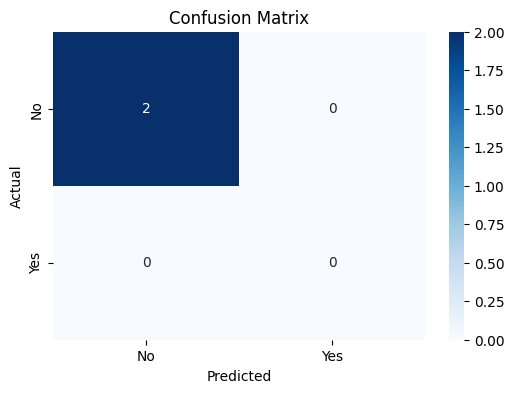

In [14]:
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [15]:
print("Decision Tree Rules:")
print(tree.export_text(model, feature_names=['Age', 'Income']))

Decision Tree Rules:
|--- Age <= 29.50
|   |--- class: 0
|--- Age >  29.50
|   |--- class: 1



In [16]:
new_person = pd.DataFrame({
    'Age': [36],
    'Income': [52]
})

prediction = model.predict(new_person)

if prediction[0] == 1:
    print("Prediction: Yes, the person is likely to buy a house.")
else:
    print("Prediction: No, the person is unlikely to buy a house.")

Prediction: Yes, the person is likely to buy a house.


In [17]:
probability = model.predict_proba(new_person)

print("Prediction probabilities:")
print("No :", probability[0][0])
print("Yes:", probability[0][1])

Prediction probabilities:
No : 0.0
Yes: 1.0


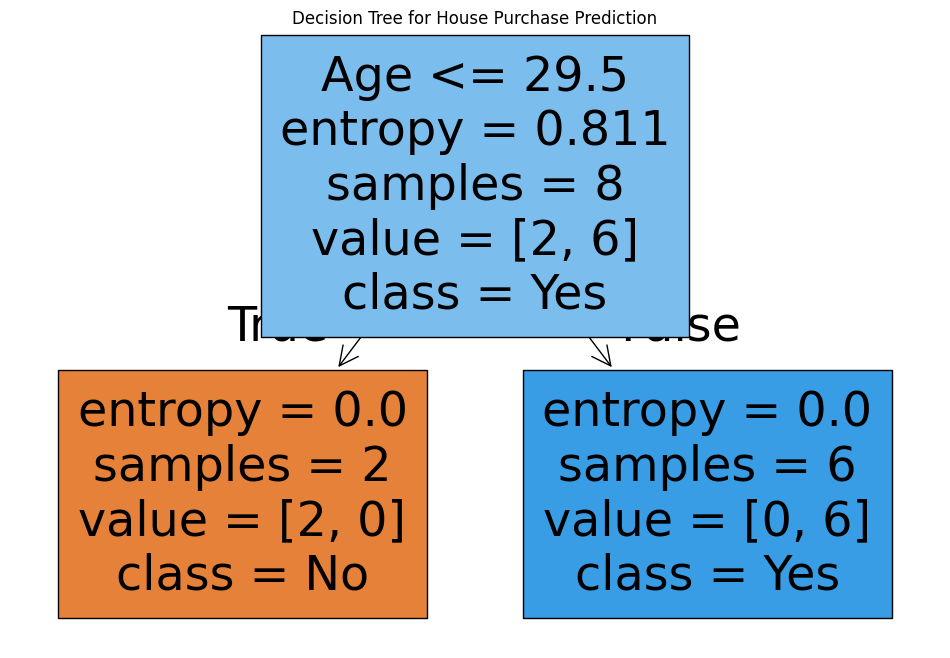

In [18]:
plt.figure(figsize=(12, 8))

tree.plot_tree(
    model,
    feature_names=['Age', 'Income'],
    class_names=['No', 'Yes'],
    filled=True
)

plt.title("Decision Tree for House Purchase Prediction")
plt.savefig("decision_tree.png", dpi=300, bbox_inches='tight')
plt.show()

In [19]:
precision = metrics.precision_score(y_test, y_pred, zero_division=0)
recall = metrics.recall_score(y_test, y_pred, zero_division=0)
f1 = metrics.f1_score(y_test, y_pred, zero_division=0)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precision: 0.0
Recall: 0.0
F1-Score: 0.0


In [21]:
print("Actual values:", y_test.values)
print("Predicted values:", y_pred)

Actual values: [0 0]
Predicted values: [0 0]


In [23]:
print("Classification Report:")

print(metrics.classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=['No', 'Yes'],
    zero_division=0
))

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         2
         Yes       0.00      0.00      0.00         0

    accuracy                           1.00         2
   macro avg       0.50      0.50      0.50         2
weighted avg       1.00      1.00      1.00         2



In [24]:
print("FINAL RESULTS")
print("-" * 40)

print("Model: Decision Tree Classifier")
print("Input Variables: Age, Income")
print("Target Variable: Buy_House")

print("\nAccuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

print("\nConfusion Matrix:")
print(confusion_matrix)

print("\nActual Test Values:", y_test.values)
print("Predicted Test Values:", y_pred)

FINAL RESULTS
----------------------------------------
Model: Decision Tree Classifier
Input Variables: Age, Income
Target Variable: Buy_House

Accuracy: 1.0
Accuracy Percentage: 100.0 %

Confusion Matrix:
[[2 0]
 [0 0]]

Actual Test Values: [0 0]
Predicted Test Values: [0 0]
